In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
sales = pd.read_csv("../data/processed/sales_clean.csv")

In [3]:
print("Customers :", customers.shape)
print("Products  :", products.shape)
print("Sales     :", sales.shape)

Customers : (7000, 7)
Products  : (200, 5)
Sales     : (30000, 7)


In [4]:
customers.head()

,customer_id,name,age,gender,location,join_date,total_spent
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34


In [5]:
products.head()

,product_id,product_name,category,price,brand
0,101,Product_101,Electronic Accessories,25.72,Brand A
1,102,Product_102,Electronic Accessories,155.32,Brand B
2,103,Product_103,Lifestyle,74.44,Brand C
3,104,Product_104,Electronic Accessories,44.43,Brand D
4,105,Product_105,Electronic Accessories,41.69,Brand E


In [6]:
products["category"].unique()

array(['Electronic Accessories', 'Lifestyle', 'Health & Beauty', 'Home',
       'Sports & Travel'], dtype=object)

In [7]:
sales.head()

,sale_id,product_id,customer_id,date,quantity,sale_price,channel
0,1,204,5647,2024-01-30,2,172.62,Online
1,2,150,6294,2024-04-12,1,58.93,Online
2,3,229,8549,2024-01-16,3,21.12,In-Store
3,4,162,7331,2024-02-10,4,37.58,Online
4,5,104,2926,2024-09-11,1,37.95,Online


In [8]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  7000 non-null   int64  
 1   name         7000 non-null   object 
 2   age          7000 non-null   int64  
 3   gender       7000 non-null   object 
 4   location     7000 non-null   object 
 5   join_date    7000 non-null   object 
 6   total_spent  7000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 382.9+ KB


In [9]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    200 non-null    int64  
 1   product_name  200 non-null    object 
 2   category      200 non-null    object 
 3   price         200 non-null    float64
 4   brand         200 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 7.9+ KB


In [10]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sale_id      30000 non-null  int64  
 1   product_id   30000 non-null  int64  
 2   customer_id  30000 non-null  int64  
 3   date         30000 non-null  object 
 4   quantity     30000 non-null  int64  
 5   sale_price   30000 non-null  float64
 6   channel      30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [11]:
#calculons le montant réel de chaque vente

sales["purchase_amount"] = (
    sales["quantity"] * sales["sale_price"]
)

In [12]:
#on regroupe les ventes par client

customer_sales = sales.groupby("customer_id").agg(
    purchase_frequency=("sale_id", "count"),
    total_quantity=("quantity", "sum"),
    sales_amount=("purchase_amount", "sum"),
    average_basket=("purchase_amount", "mean")
).reset_index()

In [13]:
customer_sales.head()

,customer_id,purchase_frequency,total_quantity,sales_amount,average_basket
0,2002,5,9,1103.79,220.758000
1,2003,6,13,1172.71,195.451667
2,2004,1,1,43.91,43.910000
3,2005,7,16,1264.34,180.620000
4,2006,3,6,391.55,130.516667


In [14]:
customer_sales.shape

(6325, 5)

In [15]:
#fusionner avec customers

customer_data = customers.merge(
    customer_sales,
    on="customer_id",
    how="left"
)

In [16]:
customer_data.head()

,customer_id,name,age,gender,location,join_date,total_spent,purchase_frequency,total_quantity,sales_amount,average_basket
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,NaN,NaN,NaN,NaN
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,5.0,9.0,1103.79,220.758000
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,6.0,13.0,1172.71,195.451667
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,1.0,1.0,43.91,43.910000
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,7.0,16.0,1264.34,180.620000


In [17]:
customer_data.shape

(7000, 11)

In [18]:
customer_data[
    ["purchase_frequency", "total_quantity", "sales_amount", "average_basket"]
] = customer_data[
    ["purchase_frequency", "total_quantity", "sales_amount", "average_basket"]
].fillna(0)

In [19]:
customer_data.head()

,customer_id,name,age,gender,location,join_date,total_spent,purchase_frequency,total_quantity,sales_amount,average_basket
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,0.0,0.0,0.00,0.000000
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,5.0,9.0,1103.79,220.758000
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,6.0,13.0,1172.71,195.451667
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,1.0,1.0,43.91,43.910000
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,7.0,16.0,1264.34,180.620000


In [20]:
customer_data.head()

,customer_id,name,age,gender,location,join_date,total_spent,purchase_frequency,total_quantity,sales_amount,average_basket
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,0.0,0.0,0.00,0.000000
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,5.0,9.0,1103.79,220.758000
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,6.0,13.0,1172.71,195.451667
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,1.0,1.0,43.91,43.910000
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,7.0,16.0,1264.34,180.620000


In [21]:
#créons notre Dataframe de Segmentation

segmentation_data = customer_data[
    [
        "customer_id",
        "age",
        "total_spent",
        "purchase_frequency",
        "total_quantity",
        "average_basket"
    ]
].copy()

segmentation_data.head()

,customer_id,age,total_spent,purchase_frequency,total_quantity,average_basket
0,2001,33,0.00,0.0,0.0,0.000000
1,2002,59,1103.79,5.0,9.0,220.758000
2,2003,51,1172.71,6.0,13.0,195.451667
3,2004,18,43.91,1.0,1.0,43.910000
4,2005,39,1264.34,7.0,16.0,180.620000


In [22]:
#séparer l'identifiant des variables

X = segmentation_data.drop(columns=["customer_id"])

In [23]:
X.head()

,age,total_spent,purchase_frequency,total_quantity,average_basket
0,33,0.00,0.0,0.0,0.000000
1,59,1103.79,5.0,9.0,220.758000
2,51,1172.71,6.0,13.0,195.451667
3,18,43.91,1.0,1.0,43.910000
4,39,1264.34,7.0,16.0,180.620000


In [24]:
X.isnull().sum()

age                   0
total_spent           0
purchase_frequency    0
total_quantity        0
average_basket        0
dtype: int64

In [25]:
X.dtypes

age                     int64
total_spent           float64
purchase_frequency    float64
total_quantity        float64
average_basket        float64
dtype: object

In [26]:
#application de standardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
X_scaled[:5]

array([[-0.24086936, -1.0418668 , -1.17006602, -1.10747283, -1.50881633],
       [ 2.24555927,  0.64409073,  0.195011  ,  0.09605281,  0.81448373],
       [ 1.48050431,  0.74936093,  0.46802641,  0.63095309,  0.54815496],
       [-1.67534741, -0.97479752, -0.89705062, -0.97374776, -1.04669896],
       [ 0.33292186,  0.88931897,  0.74104182,  1.0321283 ,  0.39206362]])

In [28]:
X_scaled.mean(axis=0)

array([-2.90053695e-16, -5.78584799e-17,  4.46626862e-17,  6.49639073e-17,
       -7.40994567e-17])

In [29]:
silhouette_scores = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.38236637757229197,
 0.2783888419202528,
 0.2712077185613103,
 0.2762549820170807,
 0.27276808189964596]

In [30]:
inertias = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

inertias

[21636.509636572235,
 16824.074976406868,
 14228.48432071097,
 11963.601447329362,
 10383.364852422994]

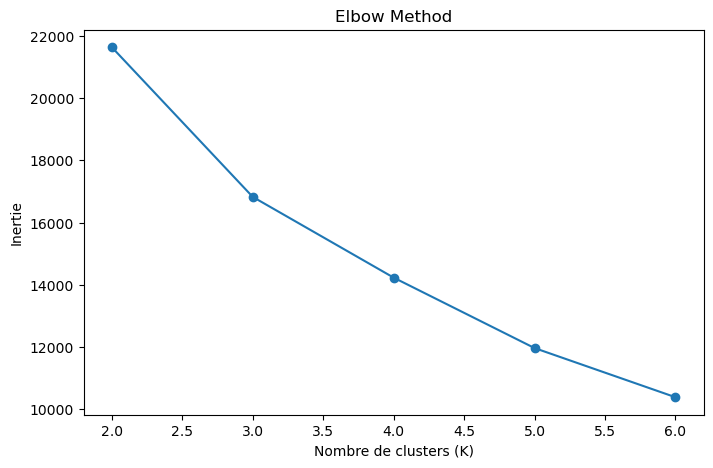

In [31]:
#graphique, on aura les deux élements
plt.figure(figsize=(8, 5))

plt.plot(range(2, 7), inertias, marker="o")

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.title("Elbow Method")

plt.show()

In [32]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_data["segment"] = kmeans_final.fit_predict(X_scaled)

In [33]:
customer_data["segment"].value_counts().sort_index()

segment
0    2962
1    1008
2    3030
Name: count, dtype: int64

In [34]:
customer_data["segment"].value_counts(normalize=True).sort_index() * 100

segment
0    42.314286
1    14.400000
2    43.285714
Name: proportion, dtype: float64

In [35]:
# Réduction de dimension avec PCA
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2","PC3"]
)

pca_df["segment"] = customer_data["segment"].values

pca_df.head()

,PC1,PC2,PC3,segment
0,-2.248792,-0.353169,-0.848831,0
1,0.730139,2.314918,0.431386,2
2,1.170334,1.508997,0.101024,2
3,-1.855596,-1.738454,-0.357672,0
4,1.586829,0.337399,-0.059906,2


In [36]:
print("Variance expliquée par PC1 :", pca.explained_variance_ratio_[0])
print("Variance expliquée par PC2 :", pca.explained_variance_ratio_[1])
print("Variance expliquée par PC2 :", pca.explained_variance_ratio_[2])
print(
    "Variance expliquée totale :",
    pca.explained_variance_ratio_.sum()
)

Variance expliquée par PC1 : 0.6038731239990849
Variance expliquée par PC2 : 0.2003001773373996
Variance expliquée par PC2 : 0.1768918325497062
Variance expliquée totale : 0.9810651338861907


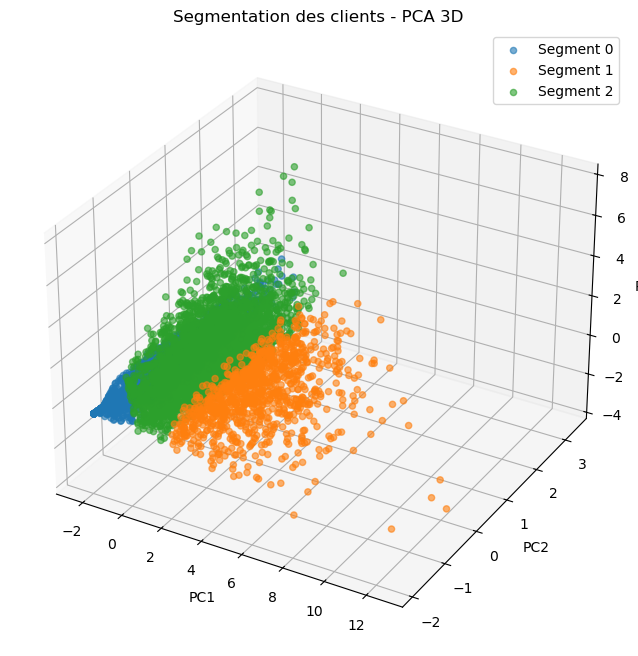

In [37]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

for segment in sorted(pca_df["segment"].unique()):

    subset = pca_df[pca_df["segment"] == segment]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        alpha=0.6,
        label=f"Segment {segment}"
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("Segmentation des clients - PCA 3D")

ax.legend()

plt.show()


In [38]:
from sklearn.cluster import KMeans

# K = 2
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_2 = kmeans_2.fit_predict(X_scaled)


# K = 3
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_3 = kmeans_3.fit_predict(X_scaled)

In [39]:
customer_data["cluster_2"] = labels_2
customer_data["cluster_3"] = labels_3

In [40]:

customer_data["cluster_3"].value_counts().sort_index()

cluster_3
0    2962
1    1008
2    3030
Name: count, dtype: int64

In [41]:
customer_data["cluster_2"].value_counts().sort_index()

cluster_2
0    2026
1    4974
Name: count, dtype: int64

In [42]:
profil_2 = customer_data.groupby("cluster_2")[
    [
        "age",
        "total_spent",
        "purchase_frequency",
        "total_quantity",
        "average_basket"
    ]
].mean()

profil_2

,age,total_spent,purchase_frequency,total_quantity,average_basket
cluster_2,,,,,
0,35.403751,1495.180656,8.620434,17.549358,186.704498
1,35.565541,350.926355,2.520105,4.506836,125.714077


In [43]:
profil_3 = customer_data.groupby("cluster_3")[
    [
        "age",
        "total_spent",
        "purchase_frequency",
        "total_quantity",
        "average_basket"
    ]
].mean()

profil_3

,age,total_spent,purchase_frequency,total_quantity,average_basket
cluster_3,,,,,
0,35.524646,166.305648,1.742404,2.670155,74.783075
1,35.326389,1881.721339,11.029762,22.388889,175.046353
2,35.576898,787.251241,4.528383,9.074257,199.871597


In [44]:
#verification

raw_customers = pd.read_csv("../data/raw/customers_data.csv")
clean_customers = pd.read_csv("../data/processed/customers_clean.csv")

print("RAW :")
print(raw_customers.columns.tolist())

print("\nPROCESSED :")
print(clean_customers.columns.tolist())

RAW :
['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Join_Date', 'Total_Spent']

PROCESSED :
['customer_id', 'name', 'age', 'gender', 'location', 'join_date', 'total_spent']


In [45]:
print("RAW :")
print(raw_customers.dtypes)

print("\nPROCESSED :")
print(clean_customers.dtypes)

RAW :
Customer_ID      int64
Name            object
Age              int64
Gender          object
Location        object
Join_Date       object
Total_Spent    float64
dtype: object

PROCESSED :
customer_id      int64
name            object
age              int64
gender          object
location        object
join_date       object
total_spent    float64
dtype: object


In [46]:
print("RAW :", raw_customers.shape)
print("PROCESSED :", clean_customers.shape)

RAW : (7000, 7)
PROCESSED : (7000, 7)


In [47]:
print("RAW :", raw_customers["Join_Date"].dtype)
print("PROCESSED :", clean_customers["join_date"].dtype)

RAW : object
PROCESSED : object


In [48]:
print("=== COMPARAISON CUSTOMERS ===")

print("Nombre de lignes :")
print("RAW       :", len(raw_customers))
print("PROCESSED :", len(clean_customers))

print("\nNombre de colonnes :")
print("RAW       :", len(raw_customers.columns))
print("PROCESSED :", len(clean_customers.columns))

print("\nColonnes RAW :")
print(raw_customers.columns.tolist())

print("\nColonnes PROCESSED :")
print(clean_customers.columns.tolist())

print("\nTypes RAW :")
print(raw_customers.dtypes)

print("\nTypes PROCESSED :")
print(clean_customers.dtypes)

=== COMPARAISON CUSTOMERS ===
Nombre de lignes :
RAW       : 7000
PROCESSED : 7000

Nombre de colonnes :
RAW       : 7
PROCESSED : 7

Colonnes RAW :
['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Join_Date', 'Total_Spent']

Colonnes PROCESSED :
['customer_id', 'name', 'age', 'gender', 'location', 'join_date', 'total_spent']

Types RAW :
Customer_ID      int64
Name            object
Age              int64
Gender          object
Location        object
Join_Date       object
Total_Spent    float64
dtype: object

Types PROCESSED :
customer_id      int64
name            object
age              int64
gender          object
location        object
join_date       object
total_spent    float64
dtype: object


In [49]:
files = {
    "customers": (
        "../data/raw/customers_data.csv",
        "../data/processed/customers_clean.csv"
    ),
    "products": (
        "../data/raw/products_data.csv",
        "../data/processed/products_clean.csv"
    ),
    "sales": (
        "../data/raw/sales_data.csv",
        "../data/processed/sales_clean.csv"
    ),
    "marketing": (
        "../data/raw/marketing_data.csv",
        "../data/processed/marketing_clean.csv"
    )
}

for name, (raw_path, clean_path) in files.items():

    raw = pd.read_csv(raw_path)
    clean = pd.read_csv(clean_path)

    print(f"\n===== {name.upper()} =====")

    print("RAW       :", raw.shape)
    print("PROCESSED :", clean.shape)

    print("\nColonnes RAW :")
    print(raw.columns.tolist())

    print("\nColonnes PROCESSED :")
    print(clean.columns.tolist())

    print("\nTypes PROCESSED :")
    print(clean.dtypes)


===== CUSTOMERS =====
RAW       : (7000, 7)
PROCESSED : (7000, 7)

Colonnes RAW :
['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Join_Date', 'Total_Spent']

Colonnes PROCESSED :
['customer_id', 'name', 'age', 'gender', 'location', 'join_date', 'total_spent']

Types PROCESSED :
customer_id      int64
name            object
age              int64
gender          object
location        object
join_date       object
total_spent    float64
dtype: object

===== PRODUCTS =====
RAW       : (200, 5)
PROCESSED : (200, 5)

Colonnes RAW :
['Product_ID', 'Product_Name', 'Category', 'Price', 'Brand']

Colonnes PROCESSED :
['product_id', 'product_name', 'category', 'price', 'brand']

Types PROCESSED :
product_id        int64
product_name     object
category         object
price           float64
brand            object
dtype: object

===== SALES =====
RAW       : (30000, 7)
PROCESSED : (30000, 7)

Colonnes RAW :
['Sale_ID', 'Product_ID', 'Customer_ID', 'Date', 'Quantity', 'Sale_Price', 'Chann

In [50]:
clean_customers.head()

,customer_id,name,age,gender,location,join_date,total_spent
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34


In [51]:
clean_customers["join_date"].head()

0    2021-12-13
1    2023-03-08
2    2021-04-29
3    2022-06-04
4    2023-01-03
Name: join_date, dtype: object

In [52]:
pd.to_datetime(clean_customers["join_date"], errors="coerce").notna().all()

np.True_

In [53]:
# Sauvegarder le résultat de la segmentation

customer_segments = customer_data[
    ["customer_id", "segment"]
].copy()

customer_segments.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

In [54]:
# Sauvegarder le résultat de la segmentation

customer_segments = customer_data.copy()

customer_segments.to_csv(
    "../data/processed/customer_segments_2.csv",
    index=False
)

In [55]:
print("Fichier customer_segments.csv créé avec succès.")
print(customer_segments.shape)
customer_segments.head()

Fichier customer_segments.csv créé avec succès.
(7000, 14)


,customer_id,name,age,gender,location,join_date,total_spent,purchase_frequency,total_quantity,sales_amount,average_basket,segment,cluster_2,cluster_3
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,0.0,0.0,0.00,0.000000,0,1,0
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,5.0,9.0,1103.79,220.758000,2,0,2
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,6.0,13.0,1172.71,195.451667,2,0,2
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,1.0,1.0,43.91,43.910000,0,1,0
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,7.0,16.0,1264.34,180.620000,2,0,2


In [56]:
customer_data

,customer_id,name,age,gender,location,join_date,total_spent,purchase_frequency,total_quantity,sales_amount,average_basket,segment,cluster_2,cluster_3
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,0.0,0.0,0.00,0.000000,0,1,0
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,5.0,9.0,1103.79,220.758000,2,0,2
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,6.0,13.0,1172.71,195.451667,2,0,2
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,1.0,1.0,43.91,43.910000,0,1,0
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,7.0,16.0,1264.34,180.620000,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,8996,Customer_8996,49,Male,Los Angeles,2023-11-10,492.34,2.0,3.0,492.34,246.170000,2,1,2
6996,8997,Customer_8997,33,Male,Phoenix,2021-05-12,647.97,4.0,9.0,647.97,161.992500,2,1,2
6997,8998,Customer_8998,18,Male,Chicago,2021-08-11,291.97,4.0,5.0,291.97,72.992500,0,1,0
6998,8999,Customer_8999,27,Female,Los Angeles,2022-03-12,158.38,2.0,4.0,158.38,79.190000,0,1,0


In [57]:
customer_data.groupby("segment")

In [58]:
customer_data["segment"].value_counts().sort_index()

segment
0    2962
1    1008
2    3030
Name: count, dtype: int64

In [59]:
repartition = (
    customer_data["segment"]
    .value_counts()
    .sort_index()
    .reset_index()
)

repartition.columns = ["Segment", "Nombre de clients"]

repartition["Répartition"] = (
    repartition["Nombre de clients"]
    / repartition["Nombre de clients"].sum()
    * 100
)

repartition["Répartition"] = (
    repartition["Répartition"]
    .map(lambda x: f"{x:.2f} %")
)

repartition

,Segment,Nombre de clients,Répartition
0,0,2962,42.31 %
1,1,1008,14.40 %
2,2,3030,43.29 %


RESUME
La clientèle est répartie en trois segments : 
42,31 % pour le segment 0, 
14,40 % pour le segment 1 et 
43,29 % pour le segment 2.
Le segment 2 est donc le plus représenté, tandis que le segment 1 est le moins représenté.